### Simplified Attention Mechanism

In [1]:
import torch
print("Pytorch version:", torch.__version__)


Pytorch version: 2.10.0+cu126


In [2]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # your     x^1
     [0.55, 0.87, 0.66], # journey  x^2
     [0.57, 0.85, 0.64], # starts   x^3
     [0.22, 0.58, 0.33], # with     x^4
     [0.77, 0.25, 0.10], # one      x^5
     [0.05, 0.80, 0.55]] # step     x^6
)

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# corresponding words for the input vectors
words = ["your", "journey", "starts", "with", "one", "step"]

# extract x,y,z coordinates
x_coords = inputs[:, 0]
y_coords = inputs[:, 1]
z_coords = inputs[:, 2]

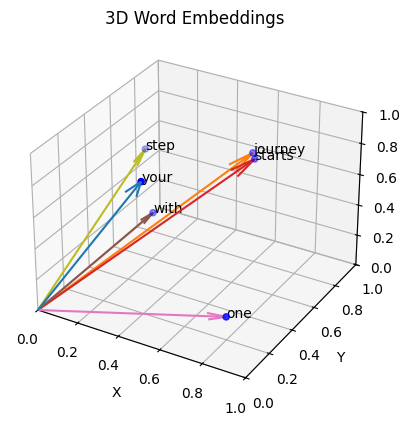

In [10]:
# 3d plot of Embedding with colored vectors
# arrow pointing from 0,0 to the point (x,y,z) for each word
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_coords, y_coords, z_coords, c='blue', marker='o')
for i, word in enumerate(words):
    ax.text(x_coords[i], y_coords[i], z_coords[i], word)
for i in range(len(words)):
    ax.quiver(0, 0, 0, x_coords[i], y_coords[i], z_coords[i], 
              color=plt.cm.tab10(i / len(words)), 
              label=words[i], 
              arrow_length_ratio=0.1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Word Embeddings')
plt.show()

QUERY: The 2nd input token serves as the query

In [12]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print("Attention scores for query 'journey':", attn_scores_2)

Attention scores for query 'journey': tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


Now we normalize the attention scores , for better interpretability

if we add 0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865 > 1, hence we can't interpret them in Percentages

Main goal of NORMALIZATION is to obtain attention weights that sum up to 1

Useful for interpretation and maintaning training stability in an LLM

In [13]:
attn_weights_2_tmp = attn_scores_2 / torch.sum(attn_scores_2)
print("Attention weights for query 'journey':", attn_weights_2_tmp)
print("Sum of attention weights:", torch.sum(attn_weights_2_tmp))

Attention weights for query 'journey': tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum of attention weights: tensor(1.0000)


In Practice, it is more common to use SOFTMAX FUNCTION for normalization

This approach is better at managing extreme values and offers more favourable gradient properties

In [14]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

In [15]:
attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights (naive softmax) for query 'journey':", attn_weights_2_naive)
print("Sum of attention weights (naive softmax):", attn_weights_2_naive.sum())

Attention weights (naive softmax) for query 'journey': tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of attention weights (naive softmax): tensor(1.)


Softmax functions ensures that the attention weights are always positive.

This makes output interpretable as probabilities or relative importance.


Naive implementation may cause numerical instability such as Overflow or Underflow when dealing with very Large or Very Small values

In [17]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights (torch.softmax) for query 'journey':", attn_weights_2)
print("Sum of attention weights (torch.softmax):", attn_weights_2.sum())

Attention weights (torch.softmax) for query 'journey': tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of attention weights (torch.softmax): tensor(1.)


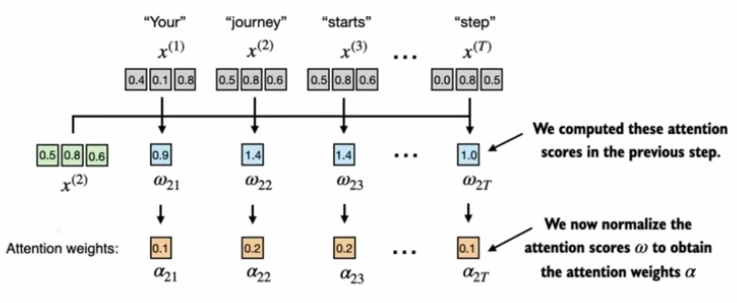

In [18]:
from IPython.display import Image
Image("images/attention_weights.png")

### Compute CONTEXT VECTOR

In [19]:
query = inputs[1]  # "journey"

context_vector_2 = torch.zeros(query.shape)

# Compute the context vector as a weighted sum of the input vectors using the attention weights
for i, x_i in enumerate(inputs):
    context_vector_2 += attn_weights_2[i] * x_i 

print("Context vector for query 'journey':", context_vector_2)

Context vector for query 'journey': tensor([0.4419, 0.6515, 0.5683])


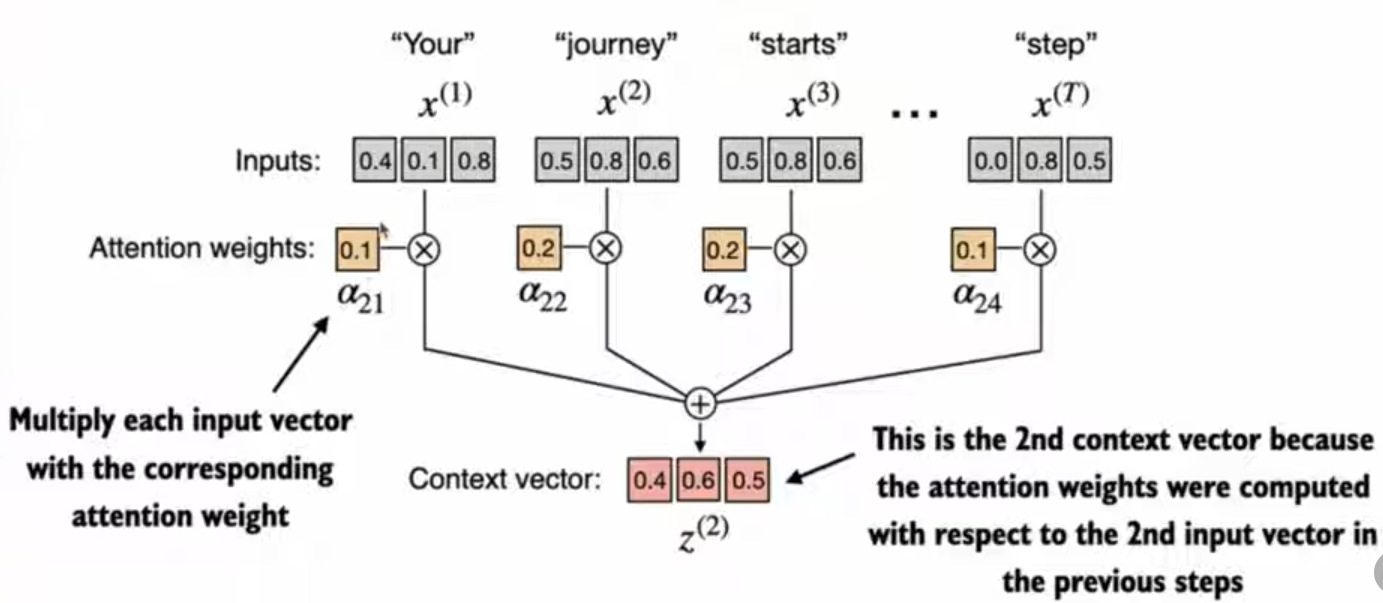

In [20]:
from IPython.display import Image
Image("images/context_vector.png")

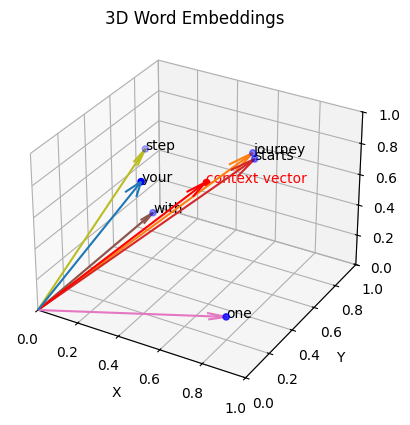

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# corresponding words for the input vectors
words = ["your", "journey", "starts", "with", "one", "step"]

# extract x,y,z coordinates
x_coords = inputs[:, 0]
y_coords = inputs[:, 1]
z_coords = inputs[:, 2]

# 3d plot of Embedding with colored vectors
# arrow pointing from 0,0 to the point (x,y,z) for each word
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_coords, y_coords, z_coords, c='blue', marker='o')
for i, word in enumerate(words):
    ax.text(x_coords[i], y_coords[i], z_coords[i], word)
for i in range(len(words)):
    ax.quiver(0, 0, 0, x_coords[i], y_coords[i], z_coords[i], 
              color=plt.cm.tab10(i / len(words)), 
              label=words[i], 
              arrow_length_ratio=0.1)
    

# plot the context vector as a red arrow 
ax.quiver(0, 0, 0, context_vector_2[0], context_vector_2[1], context_vector_2[2], 
          color='red', label='context vector', arrow_length_ratio=0.1)
# plot the value of the context vector as a red point
ax.scatter(context_vector_2[0], context_vector_2[1], context_vector_2[2], c='red', marker='o', label='context vector value')
# label the context vector point
ax.text(context_vector_2[0], context_vector_2[1], context_vector_2[2], 'context vector', color='red')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Word Embeddings')
plt.show()

### Extend computation for other inputs as well

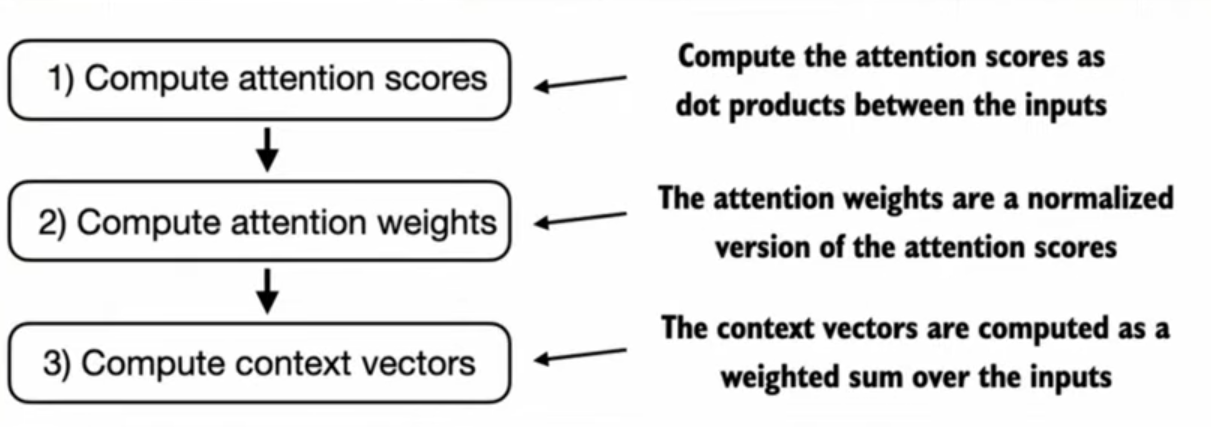

In [25]:
Image("images/attention_score_calc.png")

In [26]:
attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print("Attention scores matrix:\n", attn_scores)

Attention scores matrix:
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Each element in the tensor represents an attention score between each pair of inputs

Optimized way to do this operation (instead of 2 FOR LOOPS) is Matrix Multiplication

Matrix X Matrix.T -> this will also give same results

In [28]:
attn_scores = inputs @ inputs.T
print("Attention scores matrix (using matrix multiplication):\n", attn_scores)

Attention scores matrix (using matrix multiplication):
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


We now normalize each row, so that values in each row sum to 1

In [30]:
attn_weights = torch.softmax(attn_scores, dim=-1)

print("Attention weights matrix:\n", attn_weights)

Attention weights matrix:
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


By setting DIM = -1 , we are instructing SOFTMAX function to apply normalization along the last dimension of the attn_scores tensor i.e. COLUMNS

In [32]:
# verify the sum of each row is 1

row_sums = attn_weights.sum(dim=-1)
print("Sum of attention weights for each query (should be 1):", row_sums)

Sum of attention weights for each query (should be 1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


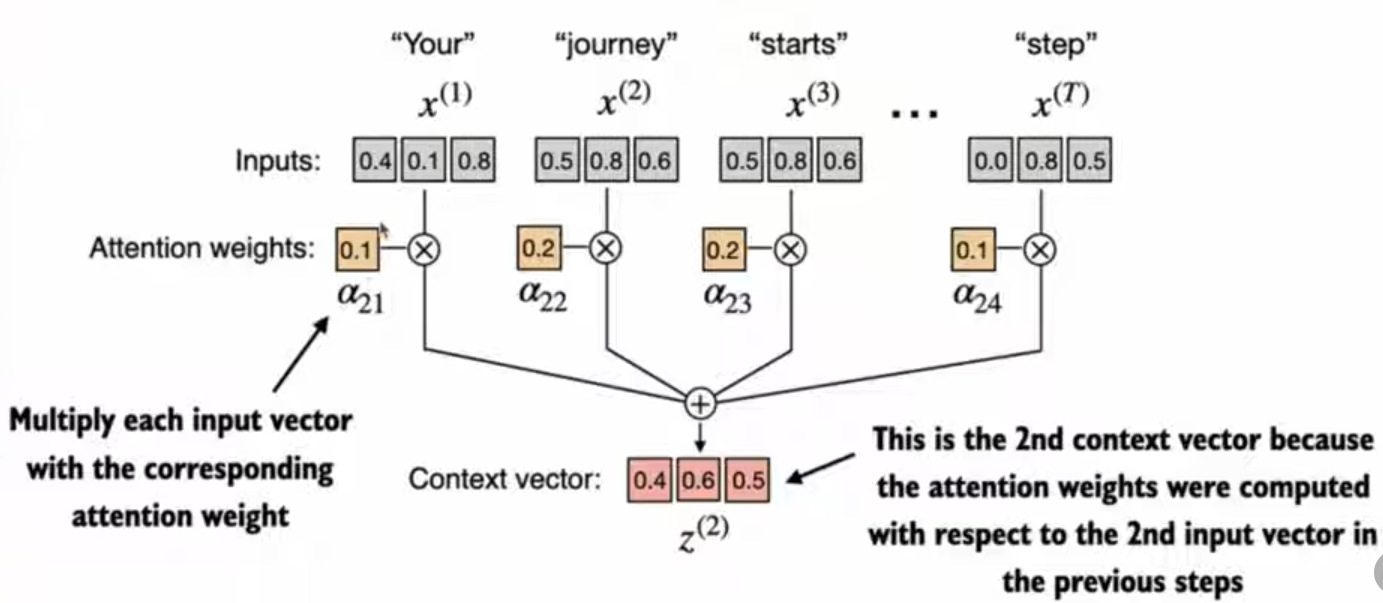

In [33]:
from IPython.display import Image
Image("images/context_vector.png")

In [34]:
all_context_vectors = attn_weights @ inputs
print("Context vectors for all queries:\n", all_context_vectors)

Context vectors for all queries:
 tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


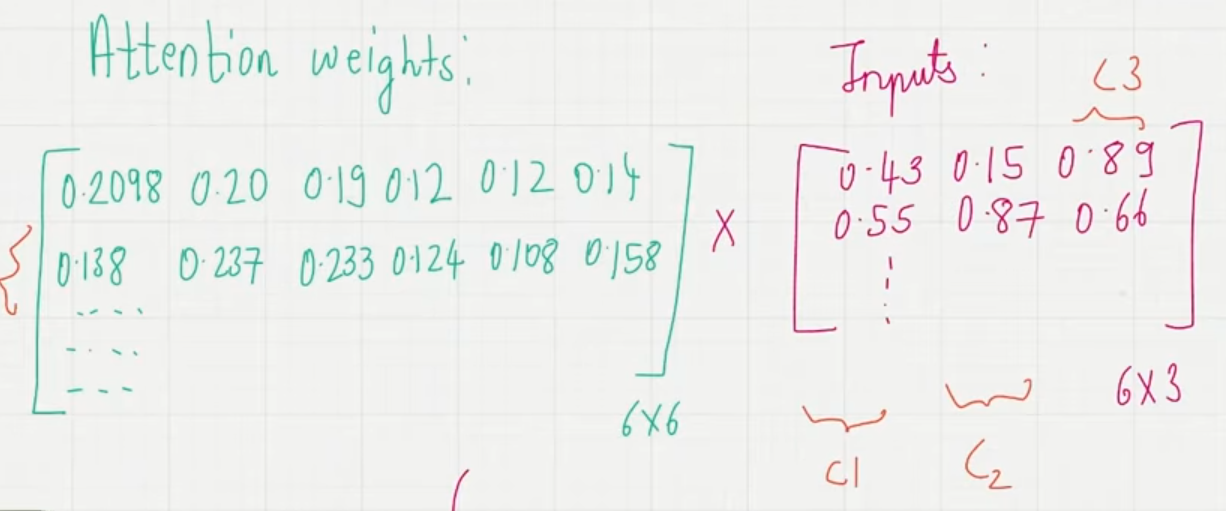

In [35]:
from IPython.display import Image
Image("images/attentio_inputs_matrix_mul.png")